### A Hebbian learning network with 1 layer

Part 1: Simulating the input data $\mathbf{x}$ and the target output $\mathbf{y}$

Part 2: Implementing Oja's Learning Rule

Part 3: Implementing Sanger's Rule

Part 4: Training the Network, and visualizing the Loss

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod
from HebbianNetwork.hebbian.models import HebbianModel, OjaNetwork, SangerNetwork

### Model Structure

In [2]:
# Base model for classic Hebbian learning
class HebbianClassic(ABC):
    """
    Base class for linear Hebbian models.

    Conventions:
      - x: shape (samples, n);
      - W (self.weights): shape (k, n), columns are neuron weight vectors
      - y = W @ x.T  -> shape (k,), by w (k,n) @ x.T (n, sample);
    """
    def __init__(self, input_size, output_size, learning_rate=0.01, rng=None):
        if input_size <= 0 or output_size <= 0:
            raise ValueError("input_size and output_size must be positive integers.")
        self.input_size = int(input_size)
        self.output_size = int(output_size)
        self.learning_rate = float(learning_rate)
        self.rng = np.random.default_rng(rng)
        # small random init; columns are neurons
        self.weights = 0.01 * self.rng.standard_normal((self.output_size, self.input_size))


    def forward(self, x):
        """
        Purpose: Compute the output of the network y = W @ x.T
        x: shape (n, 1), online learning (one sample)
        w: shape (k, n)
        returns y: shape ()
        """
        x = np.asarray(x, dtype=float).reshape(-1)
        if x.shape[0] != self.input_size:
            raise ValueError(f"x has shape {x.shape}, expected ({self.input_size},)")
        return self.weights @ x.T  # (k,)

    @abstractmethod
    def step(self, x):
        """
        Perform one online update with sample x. It is an abstract method, and should be implemented by the subclass.
        Must:
        compute y = forward(x)
        update self.weights in-place
        return y (shape (k,))
        """
        raise NotImplementedError

    def train(self, X, epochs=1, shuffle=True):
        """
        Online training over X for 'epochs' passes.
        X: array-like of shape (sample, n)
        """
        X = np.asarray(X, dtype=float)
        if X.ndim != 2 or X.shape[1] != self.input_size:
            raise ValueError(f"X has shape {X.shape}, expected (N, {self.input_size})")
        N = X.shape[0]
        for _ in range(int(epochs)):
            idx = np.arange(N)
            if shuffle:
                self.rng.shuffle(idx)
            for t, i in enumerate(idx):
                y = self.step(X[i])
                    
    # convenience
    @property
    def W(self):
        return self.weights

    def normalize_row(self, epsilon=1e-12):
        """Optional: normalize each neuron to unit norm."""
        norms = np.linalg.norm(self.weights, axis=1, keepdims=True) + epsilon
        self.weights /= norms

    

### Oja's multi-neuron model
$$
\mathbf{x \in \mathbb{R}^n}
$$

$$
\mathbf{y = Wx \in \mathbb{R}^m}
$$

$$
\mathbf{yx^\top \in \mathbb{R}^{m \times n}}
$$
$$
\mathbf{W \in \mathbb{R}^{m \times n}}
$$
$$
\mathbf{yy^\top = \mathbb{R}^{k \times k}}
$$

$$
\mathbf{\Delta W = \eta (yx^\top - y y^\top W)}
$$


In [3]:
class OjaNetwork(HebbianClassic):
  
    """
    Multi-output Oja "subspace rule":
      W <- W + eta * ( x y^T - W (y y^T) ),  y = W^T x
    Learns the PC subspace spanned by top-k PCs (order not enforced).
    """
    def __init__(self, input_size, output_size, learning_rate, rng=None):
        super().__init__(input_size, output_size, learning_rate, rng=rng)
    def step(self, x):
        x = np.asarray(x, dtype=float).reshape(-1)           # (n,)
        y = self.forward(x)                                  # (k,)
        # ΔW = eta * ( y x^T - y y^T w )                   # yx^T is (k, n); y y^T W is (k, n)
        self.weights += self.learning_rate * (np.outer(y, x) - np.outer(y, y) @ self.weights)
        return y

### Sanger's multi-neuron model

$$
\mathbf{yy^\top = \begin{bmatrix}
    y_1 y_1 & y_1 y_2 & \cdots & y_1 y_k \\
    y_2 y_1 & y_2 y_2 & \cdots & y_2 y_k \\
    \vdots & \vdots & \ddots & \vdots \\
    y_k y_1 & y_k y_2 & \cdots & y_k y_k
\end{bmatrix}}
$$

$$
\mathbf{B = \begin{bmatrix}
    y_1 y_1 & 0 & \cdots & 0 \\
    y_2 y_1 & y_2 y_2 & \cdots & 0 \\
    \vdots & \vdots & \ddots & \vdots \\
    y_k y_1 & y_k y_2 & \cdots & y_k y_k
\end{bmatrix}}
$$

$$
\mathbf{\Delta W = \eta (y x^\top - B W)}
$$



In [4]:
class SangerNetwork(HebbianClassic):
    def __init__(self, input_size, output_size, learning_rate, rng=None):
        super().__init__(input_size, output_size, learning_rate, rng=rng)

    def step(self, x):
        x = np.asarray(x, dtype=float).reshape(-1)
        y = self.forward(x)
        # ΔW = eta * (yx^T - BW), B is the lower triangular matrix of y y^T
        B = np.tril(np.outer(y, y))
        self.weights += self.learning_rate * (np.outer(y,x) - B @ self.weights)
        return y

### Training and testing: alignment to PCs

In [5]:
def pca_topk(X, k, center=True):
    """
    PCA via SVD. Returns the top-k principal components.

    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Input data (each row is a sample).
    k : int
        Number of principal components to keep (1 <= k <= min
        (n_samples, n_features)).
    center : bool, default True
        If True, subtract column means before SVD.

    Returns
    -------
    pcs : ndarray, shape (n_features, k)
        Principal directions (each column is a PC vector).
    eigvals : ndarray, shape (k,)
        Eigenvalues (variances) along those PCs.
    """
    X = np.asarray(X, dtype=float)
    n, d = X.shape
    if not (1 <= k <= min(n, d)):
        raise ValueError(f"k must be in [1, {min(n, d)}], got {k}.")

    mean_ = X.mean(axis=0) if center else np.zeros(d)
    Xc = X - mean_ if center else X

    # SVD: Xc = U S Vt  (Vt rows are PCs)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    pcs = Vt[:k].T                    # (d, k)
    # Eigenvalues of covariance = S^2 / (n-1)
    eigvals_full = (S**2) / (n - 1 if n > 1 else 1)
    eigvals = eigvals_full[:k]

    return pcs, eigvals

def cosine_alignment(u, v):
    """|cos(theta)| between two vectors u, v."""
    u = u / (np.linalg.norm(u) + 1e-12)
    v = v / (np.linalg.norm(v) + 1e-12)
    return float(abs(u @ v))


def testing_alignment(model, X, epochs, pcs, shuffle=False, method="epochs"):
    """
    Record cosine alignment(s) while training, either:
      - per epoch  (method='epochs'): one snapshot after each epoch
      - per trials (method='trials'): snapshot after each step
    """
    X = np.asarray(X, float)
    N = len(X)
    align_hist = []

    def align_from_W(W):
        # single-output
        if W.ndim == 1 or (W.ndim == 2 and W.shape[0] == 1):
            w = W if W.ndim == 1 else W[0, :]
            return cosine_alignment(w, pcs[0])
        else:
            m = min(W.shape[0], len(pcs))
            return [cosine_alignment(W[i, :], pcs[i]) for i in range(m)]

    for _ in range(int(epochs)):
        if method == "epochs":
            model.train(X, epochs=1, shuffle=shuffle)  # one epoch
            align_hist.append(align_from_W(model.W))
        elif method == "trials":
            idx = np.arange(N)
            if shuffle:
                model.rng.shuffle(idx)
            for i in idx:
                model.step(X[i])
                align_hist.append(align_from_W(model.W))
        else:
            raise ValueError("method must be 'epochs' or 'trials'.")
    return align_hist

def random_vector_chance_prob(input_size):
    return np.sqrt(2/(np.pi * input_size))

#--------------------------------
# Visualization functions
#--------------------------------

def visualize_alignment(hist_list, label_list, input_size, xlabel = "epochs"):
    """
    This function takes the history of the previous weights from different models to visualize the 
    alignment between weights and eigenvector. 
    hist_list: list;
    label_list: list;
    """
    figure = plt.figure(figsize=(15, 5), dpi=100)
    for hist, label in zip(hist_list, label_list):
        plt.plot(hist, label=label)
    
    # plot the chance level fitting in random vector
    plt.axhline(random_vector_chance_prob(input_size=input_size), label="chance_level", color = 'black', linestyle="--")
    plt.xlabel(xlabel)
    plt.ylabel("Alignment to PC (|cos θ|)")
    plt.ylim(0, 1.01)
    plt.legend()
    plt.show()

def plot_samples_and_top2_pcs(X, center=True, scale=2.5, annotate=True, ax=None):
    """
    Visualize samples and the first two principal components (PCs).

    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Input samples (rows = samples).
    center : bool, default True
        Subtract column means before PCA.
    scale : float, default 2.5
        How long to draw PC arrows (in units of sqrt(eigenvalue)).
    annotate : bool, default True
        Whether to label the PC arrows with names and eigenvalues.
    ax : matplotlib Axes or None
        If provided, draw on this axes; otherwise create a new figure.

    Returns
    -------
    info : dict with keys:
        'pcs'     : (n_features, 2) first two principal directions (columns)
        'eigvals' : (2,) eigenvalues (variances) for PC1, PC2
    """
    X = np.asarray(X, dtype=float)
    n, d = X.shape

    mean = X.mean(axis=0) if center else np.zeros(d)
    Xc = X - mean if center else X

    # PCA via SVD
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    # PCs are columns of V = Vt.T; eigenvalues = S^2/(n-1)
    V = Vt.T
    eigvals_full = (S**2) / (n - 1 if n > 1 else 1)

    # order by descending variance
    order = np.argsort(eigvals_full)[::-1]
    V = V[:, order]
    eigvals = eigvals_full[order]

    # What to plot:
    if d == 2:
        # plot in original centered coordinates
        Xplot = Xc
        # PCs are already in data coordinates
        P = V[:, :2]                # (2,2)
        lam = eigvals[:2]
        origin = np.zeros(2)
        xlabel, ylabel = "x1 (centered)", "x2 (centered)"
    else:
        # project data to first two PCs (scores)
        P = V[:, :2]                # (d,2)
        lam = eigvals[:2]
        Xplot = Xc @ P              # (n,2)
        origin = np.zeros(2)
        xlabel, ylabel = "PC1 score", "PC2 score"

    # plotting
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    ax.scatter(Xplot[:, 0], Xplot[:, 1], s=10, alpha=0.6)
    ax.axhline(0, lw=0.6)
    ax.axvline(0, lw=0.6)

    # draw arrows for PC1 and PC2
    # length ∝ sqrt(eigenvalue); scaled by 'scale'
    if d == 2:
        # arrows in original coordinates
        for i in range(2):
            vec = scale * np.sqrt(lam[i]) * P[:, i]
            ax.arrow(origin[0], origin[1], vec[0], vec[1],
                     length_includes_head=True, head_width=0.05*np.linalg.norm(vec),
                     linewidth=2)
            if annotate:
                ax.text(vec[0]*1.05, vec[1]*1.05, f"PC{i+1}\nλ={lam[i]:.3f}")
    else:
        # In projected space, PCs are coordinate axes; draw aligned arrows
        for i in range(2):
            vec = np.zeros(2)
            vec[i] = scale * np.sqrt(lam[i])
            ax.arrow(origin[0], origin[1], vec[0], vec[1],
                     length_includes_head=True, head_width=0.05*np.linalg.norm(vec),
                     linewidth=2)
            if annotate:
                ax.text(vec[0]*1.05, vec[1]*1.05, f"PC{i+1}\nλ={lam[i]:.3f}")

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title("Samples and top-2 PCs")

    return {"pcs": V[:, :2], "eigvals": eigvals[:2], "mean": mean}

from mpl_toolkits.mplot3d import Axes3D
def _set_axes_equal_3d(ax):
    """Make 3D axes have equal scale."""
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()
    x_range = abs(x_limits[1] - x_limits[0])
    x_mid = np.mean(x_limits)
    y_range = abs(y_limits[1] - y_limits[0])
    y_mid = np.mean(y_limits)
    z_range = abs(z_limits[1] - z_limits[0])
    z_mid = np.mean(z_limits)
    radius = 0.5 * max([x_range, y_range, z_range])
    ax.set_xlim3d([x_mid - radius, x_mid + radius])
    ax.set_ylim3d([y_mid - radius, y_mid + radius])
    ax.set_zlim3d([z_mid - radius, z_mid + radius])

def plot_samples_and_top3_pcs_3d(X, center=True, scale=2.5, annotate=True, ax=None):
    """
    Visualize (n,3) samples and the top three principal components in 3D.

    Parameters
    ----------
    X : array-like, shape (n_samples, 3)
        Input samples (rows = samples).
    center : bool, default True
        Subtract column means before PCA.
    scale : float, default 2.5
        Scales arrow lengths; each arrow length is scale * sqrt(eigenvalue).
    annotate : bool, default True
        Label arrows with PC index and eigenvalue.
    ax : mpl_toolkits.mplot3d.Axes3D or None
        If provided, draw on this axes; otherwise create a new 3D figure.

    Returns
    -------
    info : dict with keys
        'pcs'     : (3, 3) principal directions as columns (PC1..PC3)
        'eigvals' : (3,) eigenvalues (variances) for PC1..PC3
        'mean'    : (3,) mean vector used for centering
    """
    X = np.asarray(X, dtype=float)
    n, d = X.shape
    assert d == 3, f"Expected X to have 3 features, got {d}"

    mean = X.mean(axis=0) if center else np.zeros(d)
    Xc = X - mean if center else X

    # PCA via SVD on centered data
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    V = Vt.T                                 # PCs as columns
    eigvals_full = (S**2) / (n - 1 if n > 1 else 1)

    # sort by descending eigenvalue (usually already sorted, but be safe)
    order = np.argsort(eigvals_full)[::-1]
    V = V[:, order]
    eigvals = eigvals_full[order]

    # plotting
    if ax is None:
        fig = plt.figure(figsize=(7, 6))
        ax = fig.add_subplot(111, projection='3d')

    # scatter centered data (easier to see PCs)
    ax.scatter(Xc[:, 0], Xc[:, 1], Xc[:, 2], s=8, alpha=0.2)

    # draw arrows for each PC from the origin (in centered coords)
    for i in range(3):
        vec = scale * np.sqrt(eigvals[i]) * V[:, i]   # length ∝ sqrt(λ_i)
        ax.quiver(0.0, 0.0, 0.0,
                  vec[0], vec[1], vec[2],
                  arrow_length_ratio=0.1, linewidth=2, color='black', alpha=1.0)
        if annotate:
            tip = 1.05 * vec
            ax.text(tip[0], tip[1], tip[2],
                    f"PC{i+1}\nλ={eigvals[i]:.3f}",
                    ha='center', va='center')

    ax.set_xlabel("x1 (centered)")
    ax.set_ylabel("x2 (centered)")
    ax.set_zlabel("x3 (centered)")
    ax.set_title("Samples and top-3 PCs (3D)")
    _set_axes_equal_3d(ax)
    return {"pcs": V, "eigvals": eigvals, "mean": mean}

In [6]:
mu1 = 0.0
std1 = 0.3
mu2 = 0.0
std2 = 0.9
orientation = np.random.random() * np.pi
number_of_neurons = 2
number_of_samples = 2000
learning_rate = 0.1
epochs = 1

### Test samples: 2D

{'pcs': array([[-0.34798065, -0.93750172],
        [-0.93750172,  0.34798065]]),
 'eigvals': array([0.79738538, 0.08434389]),
 'mean': array([ 9.88098492e-18, -1.88737914e-18])}

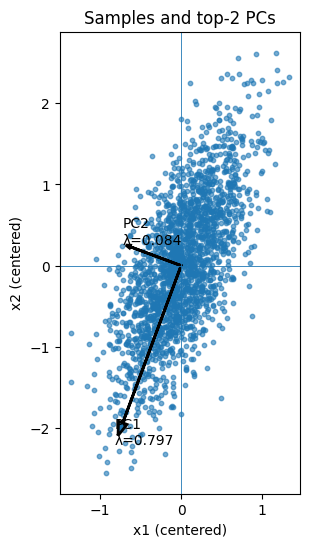

In [7]:
def gauss_distrib(theta, mu1, std1, mu2, std2, number_of_samples):
    samples = np.zeros((number_of_samples, number_of_neurons));
    for i in range(number_of_samples):
        u1 = np.random.random();
        u2 = np.random.random();
        T1 = np.sqrt(-2 * np.log(u1)) * np.cos(2*np.pi*u2);
        T2 = np.sqrt(-2 * np.log(u1)) * np.sin(2*np.pi*u2);
        
        samples[i,0] = mu1 +  (std1*T1 * np.cos(theta) - std2*T2 * np.sin(theta));
        samples[i,1] = mu2 +  (std1*T1 * np.sin(theta) + std2*T2 * np.cos(theta));	
    samples[:,0] -= np.mean(samples[:,0])
    samples[:,1] -=np.mean(samples[:,1])
    return samples

# We precompute the samples
samples_2d = gauss_distrib(orientation, mu1,std1,mu2,std2,number_of_samples)

# get eigenvalues
plot_samples_and_top2_pcs(samples_2d)

### Test samples: 3D

/var/folders/gz/j8z1vy514q51r1gxg3zf8s_h0000gn/T/ipykernel_67581/1885478904.py:5: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples_3d = np.random.multivariate_normal(mu, cov, size=number_of_samples)


{'pcs': array([[-0.25091965,  0.96761695,  0.02750933],
        [-0.58135191, -0.1733555 ,  0.79497033],
        [-0.77399567, -0.18348108, -0.60602426]]),
 'eigvals': array([1.55353724, 0.20255183, 0.09320038]),
 'mean': array([ 3.55271368e-18, -1.47659662e-17, -8.89566198e-17])}

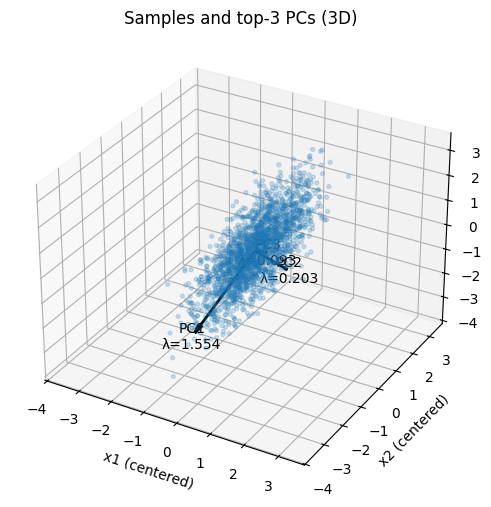

In [8]:
mu = np.array([0.0, 0.0, 0.0])   # means for 3 neurons
cov = np.array([[0.3, 0.2, 0.3],   # covariance matrix (3x3, symmetric, PSD)
                [0.2, 0.5, 0.8],
                [0.3, 0.8, 1.0]])
samples_3d = np.random.multivariate_normal(mu, cov, size=number_of_samples)

# Center the data (zero mean)
samples_3d -= samples_3d.mean(axis=0, keepdims=True)

plot_samples_and_top3_pcs_3d(samples_3d, center=True, scale=2.5, annotate=True)


### Test samples: N-D
N = 10

In [9]:
# 10-dimensional mean vector
mu = np.zeros(10)

# 10x10 covariance matrix (symmetric, PSD)
cov = np.array([
    [1.0, 0.8, 0.3, 0.2, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
    [0.8, 0.5, 0.2, 0.2, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
    [0.3, 0.2, 0.3, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
    [0.2, 0.2, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]
])

# sample data
samples_10d = np.random.multivariate_normal(mu, cov, size=number_of_samples)


/var/folders/gz/j8z1vy514q51r1gxg3zf8s_h0000gn/T/ipykernel_67581/2593445669.py:19: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples_10d = np.random.multivariate_normal(mu, cov, size=number_of_samples)


### training over epochs or samples

In [10]:
from multiprocessing import Value
from random import sample


def training_testing(samples, output_size=None, learning_rate=0.1, method = "epochs", pc_method = "ordered", show_num = None):
    global weights_oja1, weights_ojaK, weights_sangerK
    samples_dim = samples.shape[1]
    # get the PCs 
    pcs, _ = pca_topk(samples, samples_dim, center=True)

    if pc_method == "first":
        pc_set = [pcs[:,0] for i in range(samples_dim)]
    elif pc_method == "ordered":
        pc_set = [pcs[:,i] for i in range(samples_dim)]
    else:
        raise ValueError("Has to be 'first' or 'ordered'")

    # oja1 = OjaNetwork(input_size=samples_dim, output_size=1, learning_rate=learning_rate)
    ojaK = OjaNetwork(input_size=samples_dim, output_size=output_size, learning_rate=learning_rate)
    sangerK = SangerNetwork(input_size=samples_dim, output_size=output_size, learning_rate=learning_rate)

    # hist_oja1 = testing_alignment(oja1, samples, epochs=epochs, pcs = [pc_set[0]], method=method)

    if output_size > samples_dim:
        hist_ojaK = testing_alignment(ojaK, samples, epochs=epochs, pcs = pc_set[:samples_dim], method=method)
        hist_sangerK = testing_alignment(sangerK, samples, epochs=epochs, pcs = pc_set[:samples_dim], method=method)
    else:
        hist_ojaK = testing_alignment(ojaK, samples, epochs=epochs, pcs = pc_set, method=method)
        hist_sangerK = testing_alignment(sangerK, samples, epochs=epochs, pcs = pc_set, method=method)

    # weights_oja1 = oja1.weights.copy()
    weights_ojaK = ojaK.weights.copy()
    weights_sangerK = sangerK.weights.copy()

    ### visualize the alignment
    display_dict_oja ={}
    display_dict_sanger ={}
    # display_dict_oja1 = {}
    # display_dict_oja1["Oja-1"] = np.array(hist_oja1)

    if show_num == None:
        show_num = output_size
    for i in range(show_num):
        display_dict_oja[f"Oja-multi (neuron {i+1})"] = np.array(hist_ojaK)[:,i]
        display_dict_sanger[f"Sanger (neuron {i+1})"] = np.array(hist_sangerK)[:,i]

    visualize_alignment(list(display_dict_oja.values()), list(display_dict_oja.keys()), input_size=samples_dim, xlabel=method)
    visualize_alignment(list(display_dict_sanger.values()), list(display_dict_sanger.keys()), input_size=samples_dim, xlabel=method)



### 2D Oja and Sanger multi-neuron networks

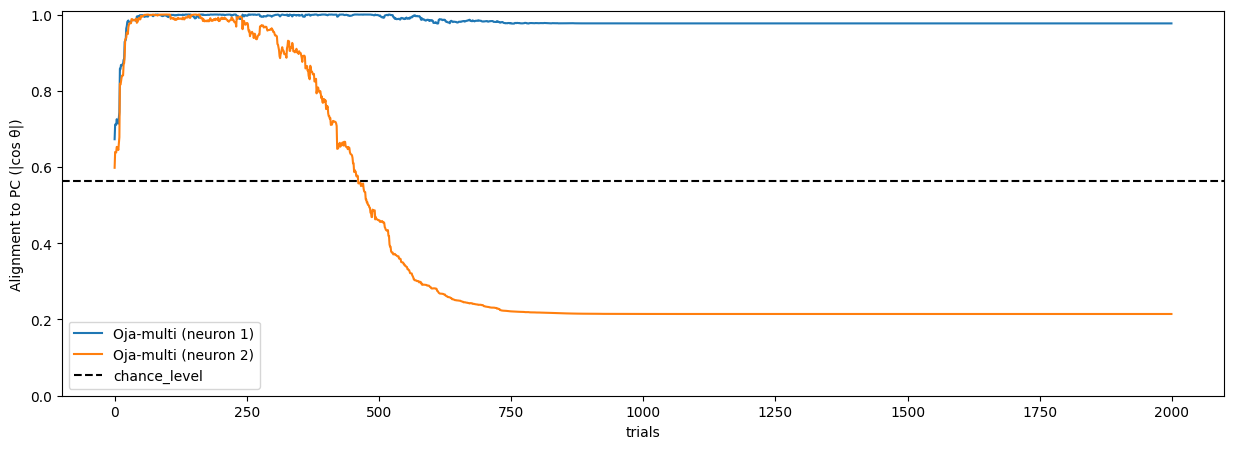

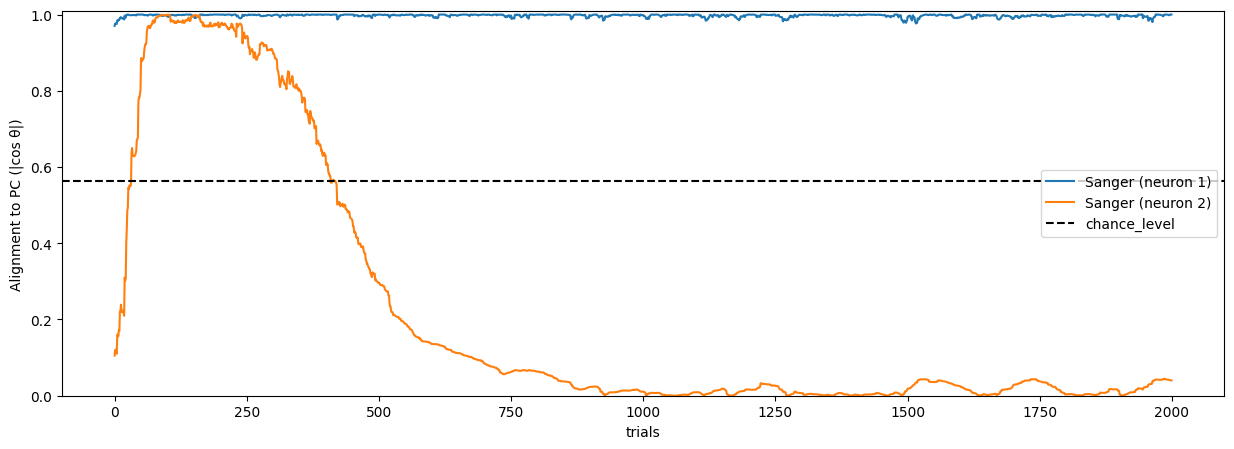

In [11]:
training_testing(samples_2d, output_size=2, learning_rate=0.1, pc_method = "first", method="trials")

### 3D Oja and Sanger multi-neuron networks

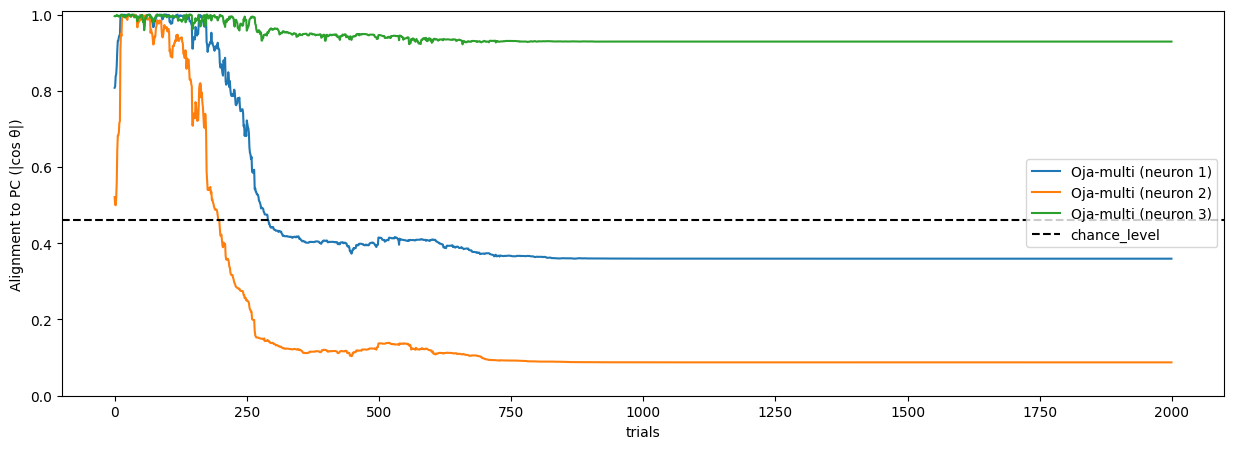

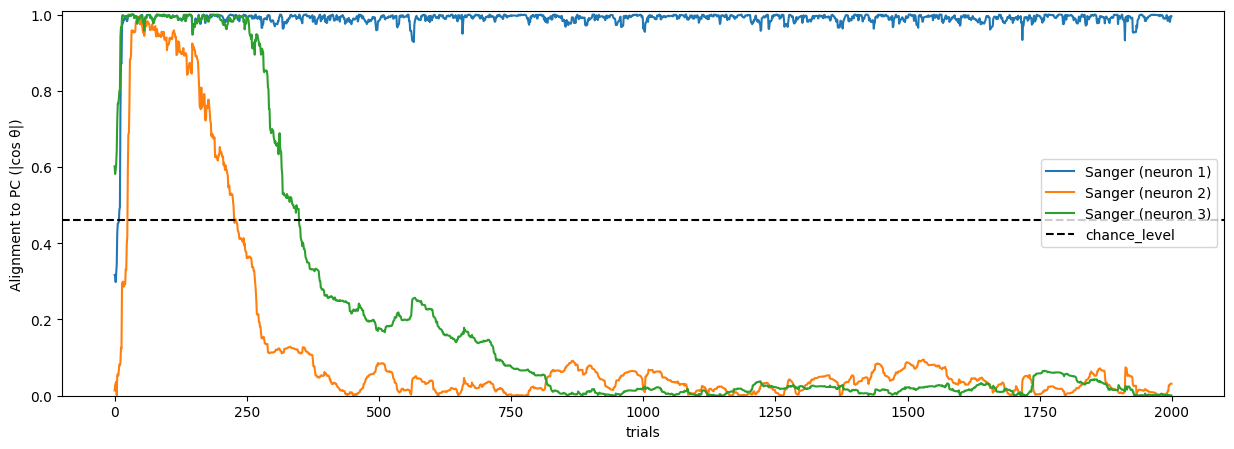

In [19]:
training_testing(samples_3d, output_size=3, learning_rate=0.1, pc_method="first", method="trials")

### 3D Oja's and Sanger's multi-neuron model in 2D samples.

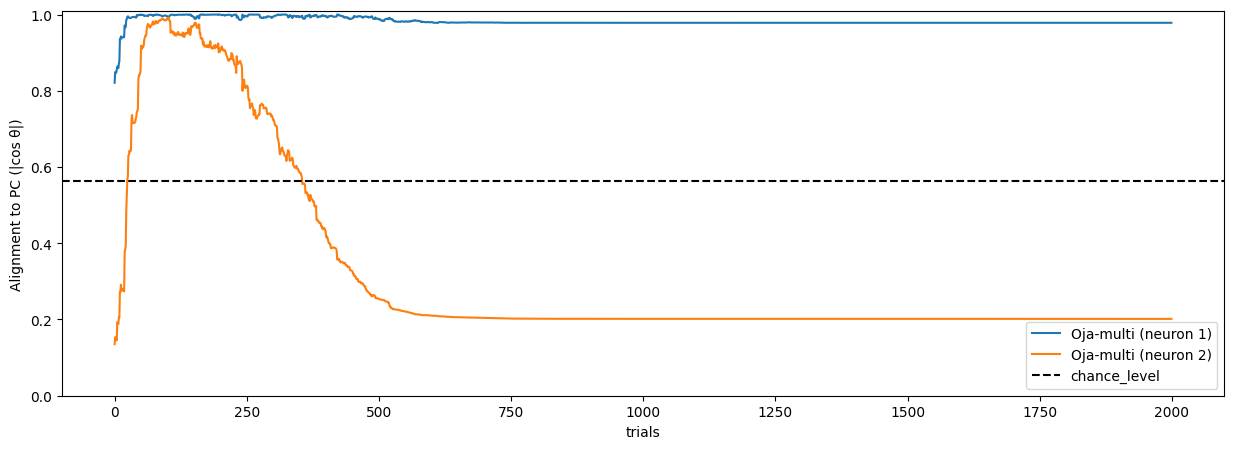

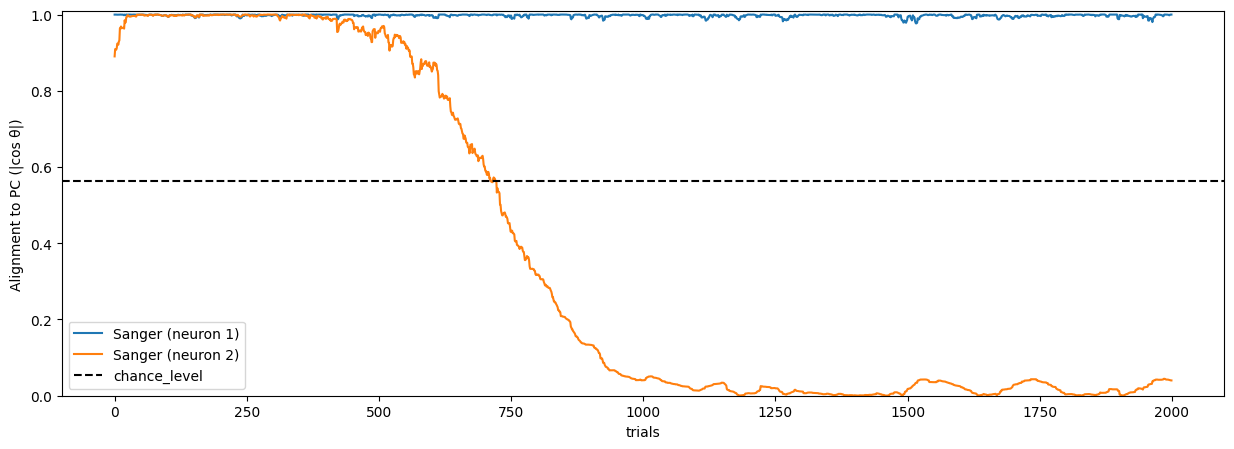

In [13]:
training_testing(samples_2d, output_size=3, learning_rate=0.1, pc_method="first", method="trials", show_num=2) 

### Oja and Sanger multi-neuron networks for N-D samples
N = 10

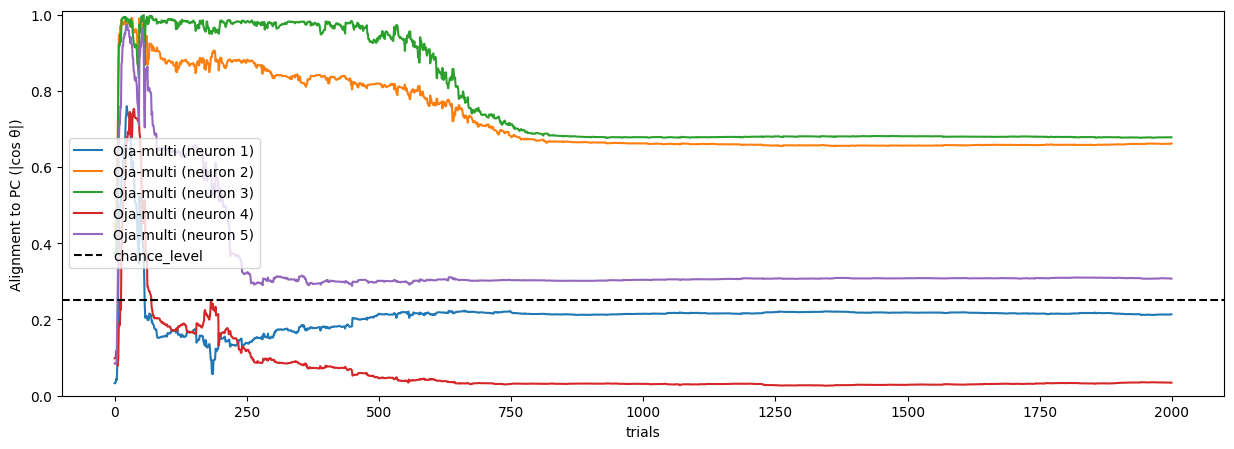

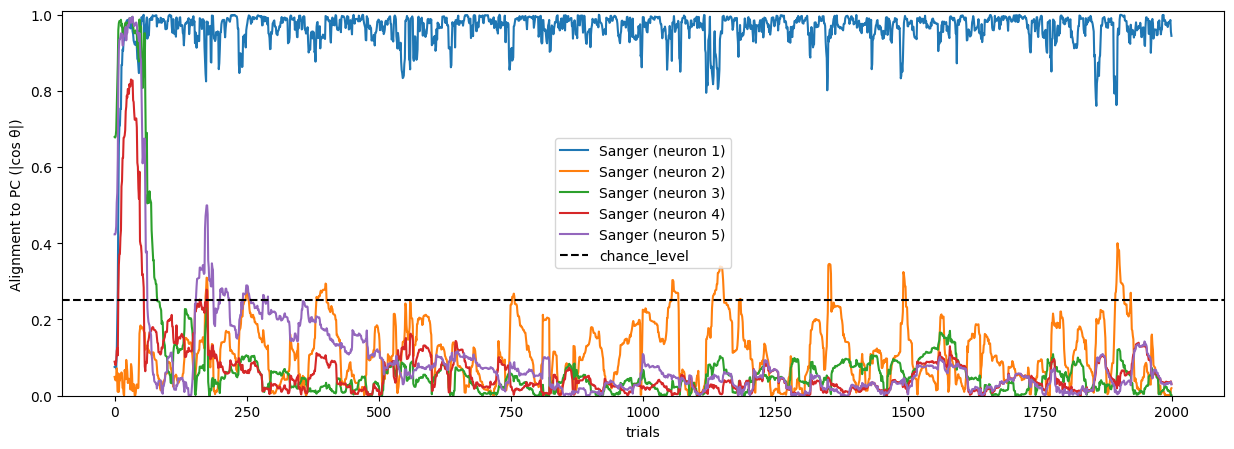

In [14]:
training_testing(samples_10d, output_size=5, learning_rate=0.1, pc_method = "first", method="trials")

### Bonus: check the variances of output to align with eigenvalues

In [15]:
def estimate_output_variances(X, weights, center=True, unit_weights=True):
    """
    Compute Var(Y) with current W on a dataset X (rows=samples).
    If center=True, subtract column means of X first (recommended).
    If unit_weights=True, normalize columns of W before projecting.
    Returns: var_y (k,), the per-output variances.
    """
    X = np.asarray(X, float)
    if center:
        X = X - X.mean(axis=0, keepdims=True)
    W = weights.copy() #(k, n)
    if unit_weights:
        W /= (np.linalg.norm(W, axis=1, keepdims=True) + 1e-12)

    Y = W@X.T                   # (k, n) x (n, samples)
    return Y.var(axis=1, ddof=1)

X = samples_10d
# Eigenvalue
print(f"PCs eigenvalues: {pca_topk(X, X.shape[1], center=True)[1]}")
print(f"Sanger: {estimate_output_variances(X, weights_sangerK)}")
print(f"Oja: {estimate_output_variances(X, weights_ojaK)}")

PCs eigenvalues: [1.87028296e+000 5.63404004e-001 1.57885908e-001 9.80752771e-002
 1.01742065e-002 3.02926543e-033 1.33742714e-065 4.05161501e-097
 2.65559793e-127 9.87515405e-158]
Sanger: [1.71130973 0.55660203 0.15774196 0.10527287 0.11727015]
Oja: [0.53127791 0.96165616 0.9143726  0.29614433 0.34925161]


### Bonus 2: Subspace check
The results of $\mathbf{w^\top w \approx I_n}$

In [16]:
print(weights_ojaK.T @ weights_ojaK)

[[ 0.96375301  0.01511293  0.02257813  0.17642318 -0.02809519 -0.02799235
  -0.02809039 -0.02807963 -0.02805531 -0.02806831]
 [ 0.01511293  0.99487186 -0.00854333 -0.06869906  0.01094731  0.01090723
   0.0109454   0.01094123  0.01093175  0.01093684]
 [ 0.02257813 -0.00854333  0.98804507 -0.1036455   0.0165852   0.01652471
   0.01658239  0.01657605  0.01656175  0.01656939]
 [ 0.17642318 -0.06869906 -0.1036455   0.18269753  0.13072123  0.13024381
   0.13069908  0.13064901  0.13053617  0.13059645]
 [-0.02809519  0.01094731  0.0165852   0.13072123  0.14593701  0.14590014
   0.14593529  0.14593143  0.14592272  0.14592737]
 [-0.02799235  0.01090723  0.01652471  0.13024381  0.14590014  0.1462306
   0.14591548  0.14595013  0.14602824  0.14598651]
 [-0.02809039  0.0109454   0.01658239  0.13069908  0.14593529  0.14591548
   0.14593437  0.1459323   0.14592761  0.14593011]
 [-0.02807963  0.01094123  0.01657605  0.13064901  0.14593143  0.14595013
   0.1459323   0.14593426  0.14593868  0.14593632]
 